In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
import warnings
warnings.filterwarnings('ignore')

In [152]:
df = pd.read_csv('cafe_sales_dirty.csv')
initial_shape = df.shape
df.sample(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
3568,TXN_8377812,Tea,2,1.5,3.0,Digital Wallet,In-store,2023-03-27
2754,TXN_6158865,Cookie,1,1.0,1.0,Digital Wallet,NaN,2023-11-27
3931,TXN_4076392,Coffee,3,2.0,6.0,NaN,In-store,2023-12-24
937,TXN_5630457,Smoothie,1,4.0,4.0,Credit Card,Takeaway,2023-03-01
3670,TXN_2037742,Cake,4,3.0,12.0,Digital Wallet,In-store,2023-11-14
9011,TXN_3749051,NaN,ERROR,4.0,12.0,NaN,Takeaway,2023-04-19
5261,TXN_6483589,Juice,3,3.0,9.0,Digital Wallet,NaN,2023-10-13
401,TXN_3884811,Coffee,4,2.0,8.0,Credit Card,NaN,2023-06-10
7380,TXN_3660227,Juice,4,3.0,12.0,Credit Card,Takeaway,2023-05-13
4088,TXN_5202349,Cookie,4,1.0,4.0,NaN,In-store,2023-11-27


In [153]:
# Clean string formatting & outliers
# Using replace as demonstrated in the reference PDF to handle bad string entries
df = df.replace(['ERROR', 'UNKNOWN'], np.nan)

In [154]:
# Convert numerical columns to float first so we can compute statistics
for col in ['Quantity', 'Price Per Unit', 'Total Spent']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [155]:
# Convert Date to datetime EARLY so we can sort and use temporal imputation
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

In [156]:
# SORT chronologically. This is crucial for forward-filling temporal data like prices.
df = df.sort_values(by='Transaction Date')

In [157]:
# 2. Advanced Statistical Imputation
# A. Item: Fill missing items using the overall mode.
df['Item'] = df['Item'].fillna(df['Item'].mode()[0])

In [158]:
# B. Price Per Unit 
# Prices depend on the Item. By grouping by Item and forward-filling/backward-filling 
df['Price Per Unit'] = df.groupby('Item')['Price Per Unit'].transform(lambda x: x.ffill().bfill())

In [159]:
# C. Quantity:Median quantity *per specific Item* is much more accurate than a global median.
df['Quantity'] = df.groupby('Item')['Quantity'].transform(lambda x: x.fillna(x.median()))
# Safety fallback if an entire category was somehow NaN
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

In [160]:
# D. Total Spent: Calculating deterministically where missing (Quantity * Price)
df['Total Spent'] = df['Total Spent'].fillna(df['Quantity'] * df['Price Per Unit'])

In [161]:
# E. Transaction Date: Forward fill missing dates assuming transactions were logged sequentially
df['Transaction Date'] = df['Transaction Date'].ffill().bfill()

In [162]:
# F. Independent Categoricals: Fill with mode
for col in ['Payment Method', 'Location']:
    df[col] = df[col].fillna(df[col].mode()[0])

In [163]:
# 3.incorrect data types and remove duplicate rows
convert_dict = {
    'Transaction ID': 'string',
    'Item': 'category',
    'Quantity': 'int32',
    'Price Per Unit': 'float32',
    'Total Spent': 'float32',
    'Payment Method': 'category',
    'Location': 'category'
    # Transaction Date is already datetime64[ns]
}
df_cleaned = df.astype(convert_dict)
df_cleaned.drop_duplicates(inplace=True)

In [164]:
#new cleaned file
df_cleaned.to_csv('cafe_sales_cleaned.csv', index=False)

In [165]:
# summary of changes
print("--- Summary of Changes Made ---")
print(f"Original Shape: {initial_shape}")
print(f"Cleaned Shape: {df_cleaned.shape}")
print(f"Rows Removed: {initial_shape[0] - df_cleaned.shape[0]}")
print("\n--- Uncleaned Data Types ---")
print(df.dtypes)
print(f"\n--- Uncleaned Missing Values ---")
print(df.isna().sum())

--- Summary of Changes Made ---
Original Shape: (10000, 8)
Cleaned Shape: (10000, 8)
Rows Removed: 0

--- Uncleaned Data Types ---
Transaction ID              object
Item                        object
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
dtype: object

--- Uncleaned Missing Values ---
Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64


In [166]:
# summary of cleaned data
print("\n--- Cleaned Data Types ---")
print(df_cleaned.dtypes)
print("\n--- Cleaned Missing Values ---")
print(df_cleaned.isna().sum())



--- Cleaned Data Types ---
Transaction ID      string[python]
Item                      category
Quantity                     int32
Price Per Unit             float32
Total Spent                float32
Payment Method            category
Location                  category
Transaction Date    datetime64[ns]
dtype: object

--- Cleaned Missing Values ---
Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64


In [167]:
df = pd.read_csv('cafe_sales_cleaned.csv')
df.sample(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
735,TXN_2461238,Coffee,1,2.0,2.0,Digital Wallet,Takeaway,2023-01-29
5745,TXN_4020100,Cookie,1,1.0,1.0,Cash,In-store,2023-08-09
9981,TXN_2827259,Tea,3,1.5,4.5,Credit Card,Takeaway,2023-12-31
1730,TXN_5337566,Cookie,5,1.0,5.0,Cash,Takeaway,2023-03-08
556,TXN_5478129,Juice,4,3.0,12.0,Credit Card,Takeaway,2023-01-22
9982,TXN_8801160,Salad,2,5.0,10.0,Cash,In-store,2023-12-31
1863,TXN_3785678,Tea,1,1.5,1.5,Credit Card,Takeaway,2023-03-13
4556,TXN_2616353,Smoothie,3,4.0,12.0,Cash,Takeaway,2023-06-24
6165,TXN_6279736,Salad,1,5.0,5.0,Digital Wallet,Takeaway,2023-08-25
6966,TXN_2539469,Cake,2,3.0,6.0,Credit Card,Takeaway,2023-09-24


Item
Juice       2140
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Name: count, dtype: int64


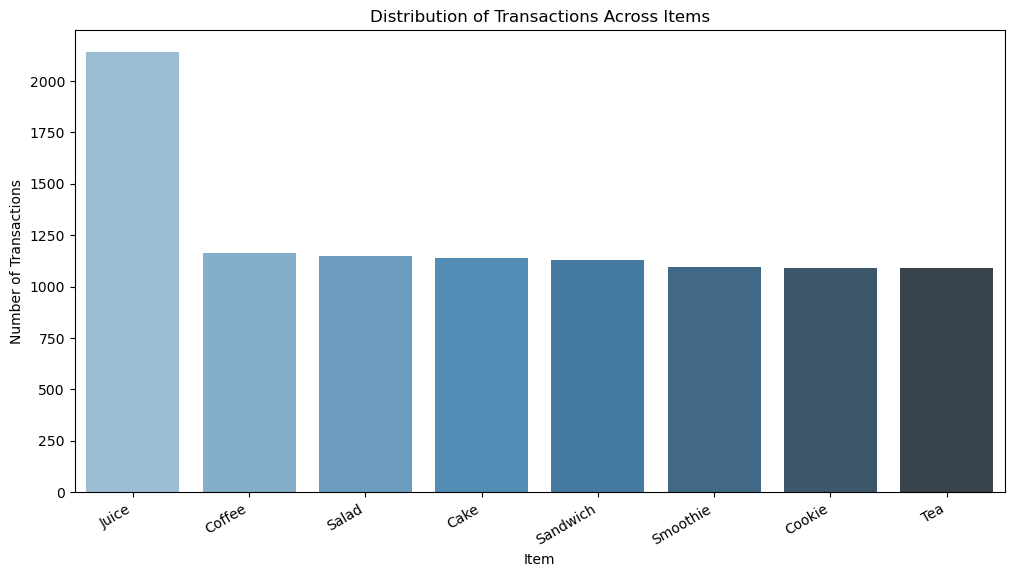

In [168]:
# cat_counts
cat_counts = df['Item'].value_counts()
print(cat_counts)

plt.figure(figsize=(12, 6))
sns.barplot(x=cat_counts.index, y=cat_counts.values, palette='Blues_d')
plt.title('Distribution of Transactions Across Items')
plt.xlabel('Item')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=30, ha='right')
plt.show()

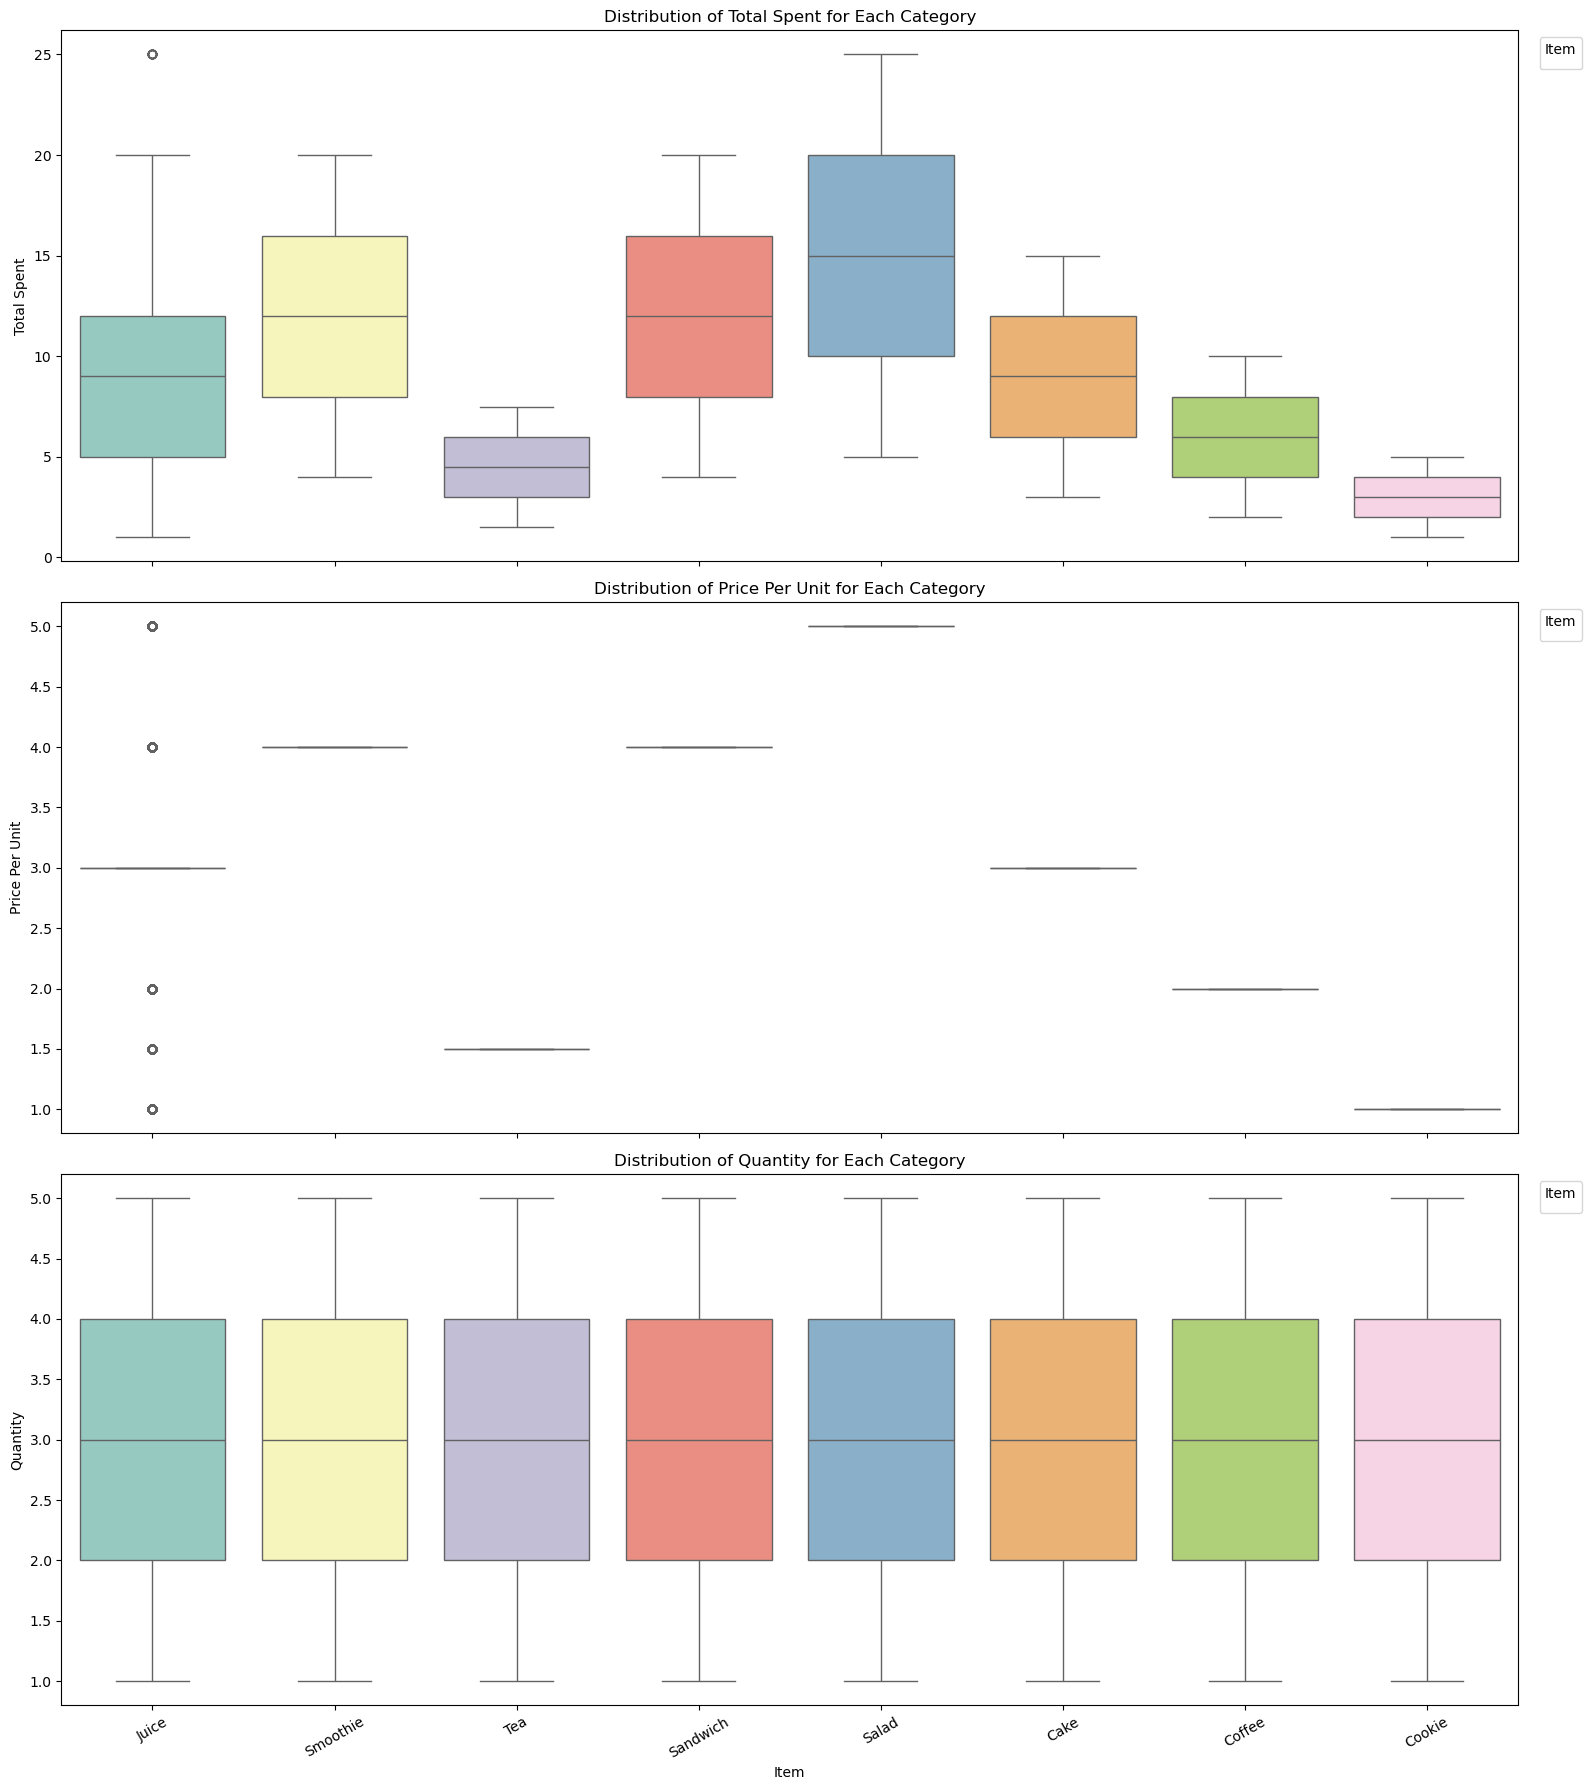

In [169]:
# 3. Subplots for distributions
fig, axes = plt.subplots(3, 1, figsize=(16, 18), sharey=False, sharex=True)

sns.boxplot(data=df, x='Item', y='Total Spent', hue='Item', palette='Set3', ax=axes[0])
axes[0].set_title('Distribution of Total Spent for Each Category')
axes[0].set_ylabel('Total Spent')
axes[0].legend(title='Item', bbox_to_anchor=(1.01, 1), loc='upper left')

sns.boxplot(data=df, x='Item', y='Price Per Unit', hue='Item', palette='Set3', ax=axes[1])
axes[1].set_title('Distribution of Price Per Unit for Each Category')
axes[1].set_ylabel('Price Per Unit')
axes[1].legend(title='Item', bbox_to_anchor=(1.01, 1), loc='upper left')

sns.boxplot(data=df, x='Item', y='Quantity', hue='Item', palette='Set3', ax=axes[2])
axes[2].set_title('Distribution of Quantity for Each Category')
axes[2].set_ylabel('Quantity')
axes[2].legend(title='Item', bbox_to_anchor=(1.01, 1), loc='upper left')

for ax in axes:
    ax.tick_params(axis='x', labelrotation=30)
plt.tight_layout()
plt.show()

In [170]:
# Aggregations
aggregations = {'Total Spent': 'sum', 
                'Price Per Unit': 'mean',
                'Quantity': 'sum'}

category_vote = df.groupby('Item').agg(aggregations).sort_values('Total Spent', ascending=False)

# Percentages
total_spent = category_vote['Total Spent'].sum()
total_quantity = category_vote['Quantity'].sum()

percent_of_total_spent = (category_vote['Total Spent'] / total_spent) * 100
percent_of_total_quantity = (category_vote['Quantity'] / total_quantity) * 100

# result_df
result_df = pd.DataFrame({
 'Total Spent (sum)': category_vote['Total Spent'], 
 '% Total Spent': percent_of_total_spent, 
 'Avg Price': category_vote['Price Per Unit'].round(2),
 'Quantity': category_vote['Quantity'],
 '% of Quantity': percent_of_total_quantity.round(2)
 })

# Print statements
max_spent_cat = result_df['Total Spent (sum)'].idxmax()
max_spent = result_df['Total Spent (sum)'].max()
avg_price = result_df.loc[max_spent_cat, 'Avg Price']

max_quant_cat = result_df['Quantity'].idxmax()
max_quant = result_df['Quantity'].max()
pct_max_quant = result_df['% of Quantity'].max()

print(f"The category '{max_spent_cat}' is The Most Revenue Generating Category of 2023, with {max_spent:,} spent")
print(f"The category '{max_quant_cat}' is The Most Sold Category of 2023, having an average price of {format(avg_price, '.2f')}, and quantity of: {max_quant:,}, or {format(pct_max_quant, '.2f')}% of total quantity")
print("\n--- Result DataFrame ---")
print(result_df)

The category 'Juice' is The Most Revenue Generating Category of 2023, with 19,081.5 spent
The category 'Juice' is The Most Sold Category of 2023, having an average price of 2.97, and quantity of: 6,435, or 21.26% of total quantity

--- Result DataFrame ---
          Total Spent (sum)  % Total Spent  Avg Price  Quantity  % of Quantity
Item                                                                          
Juice               19081.5      21.366306       2.97      6435          21.26
Salad               17375.0      19.455471       5.00      3469          11.46
Sandwich            13764.0      15.412092       4.00      3428          11.32
Smoothie            13368.0      14.968675       4.00      3353          11.08
Cake                10413.0      11.659846       3.00      3467          11.45
Coffee               7102.0       7.952389       2.00      3551          11.73
Tea                  4965.0       5.559506       1.50      3319          10.96
Cookie               3238.0     

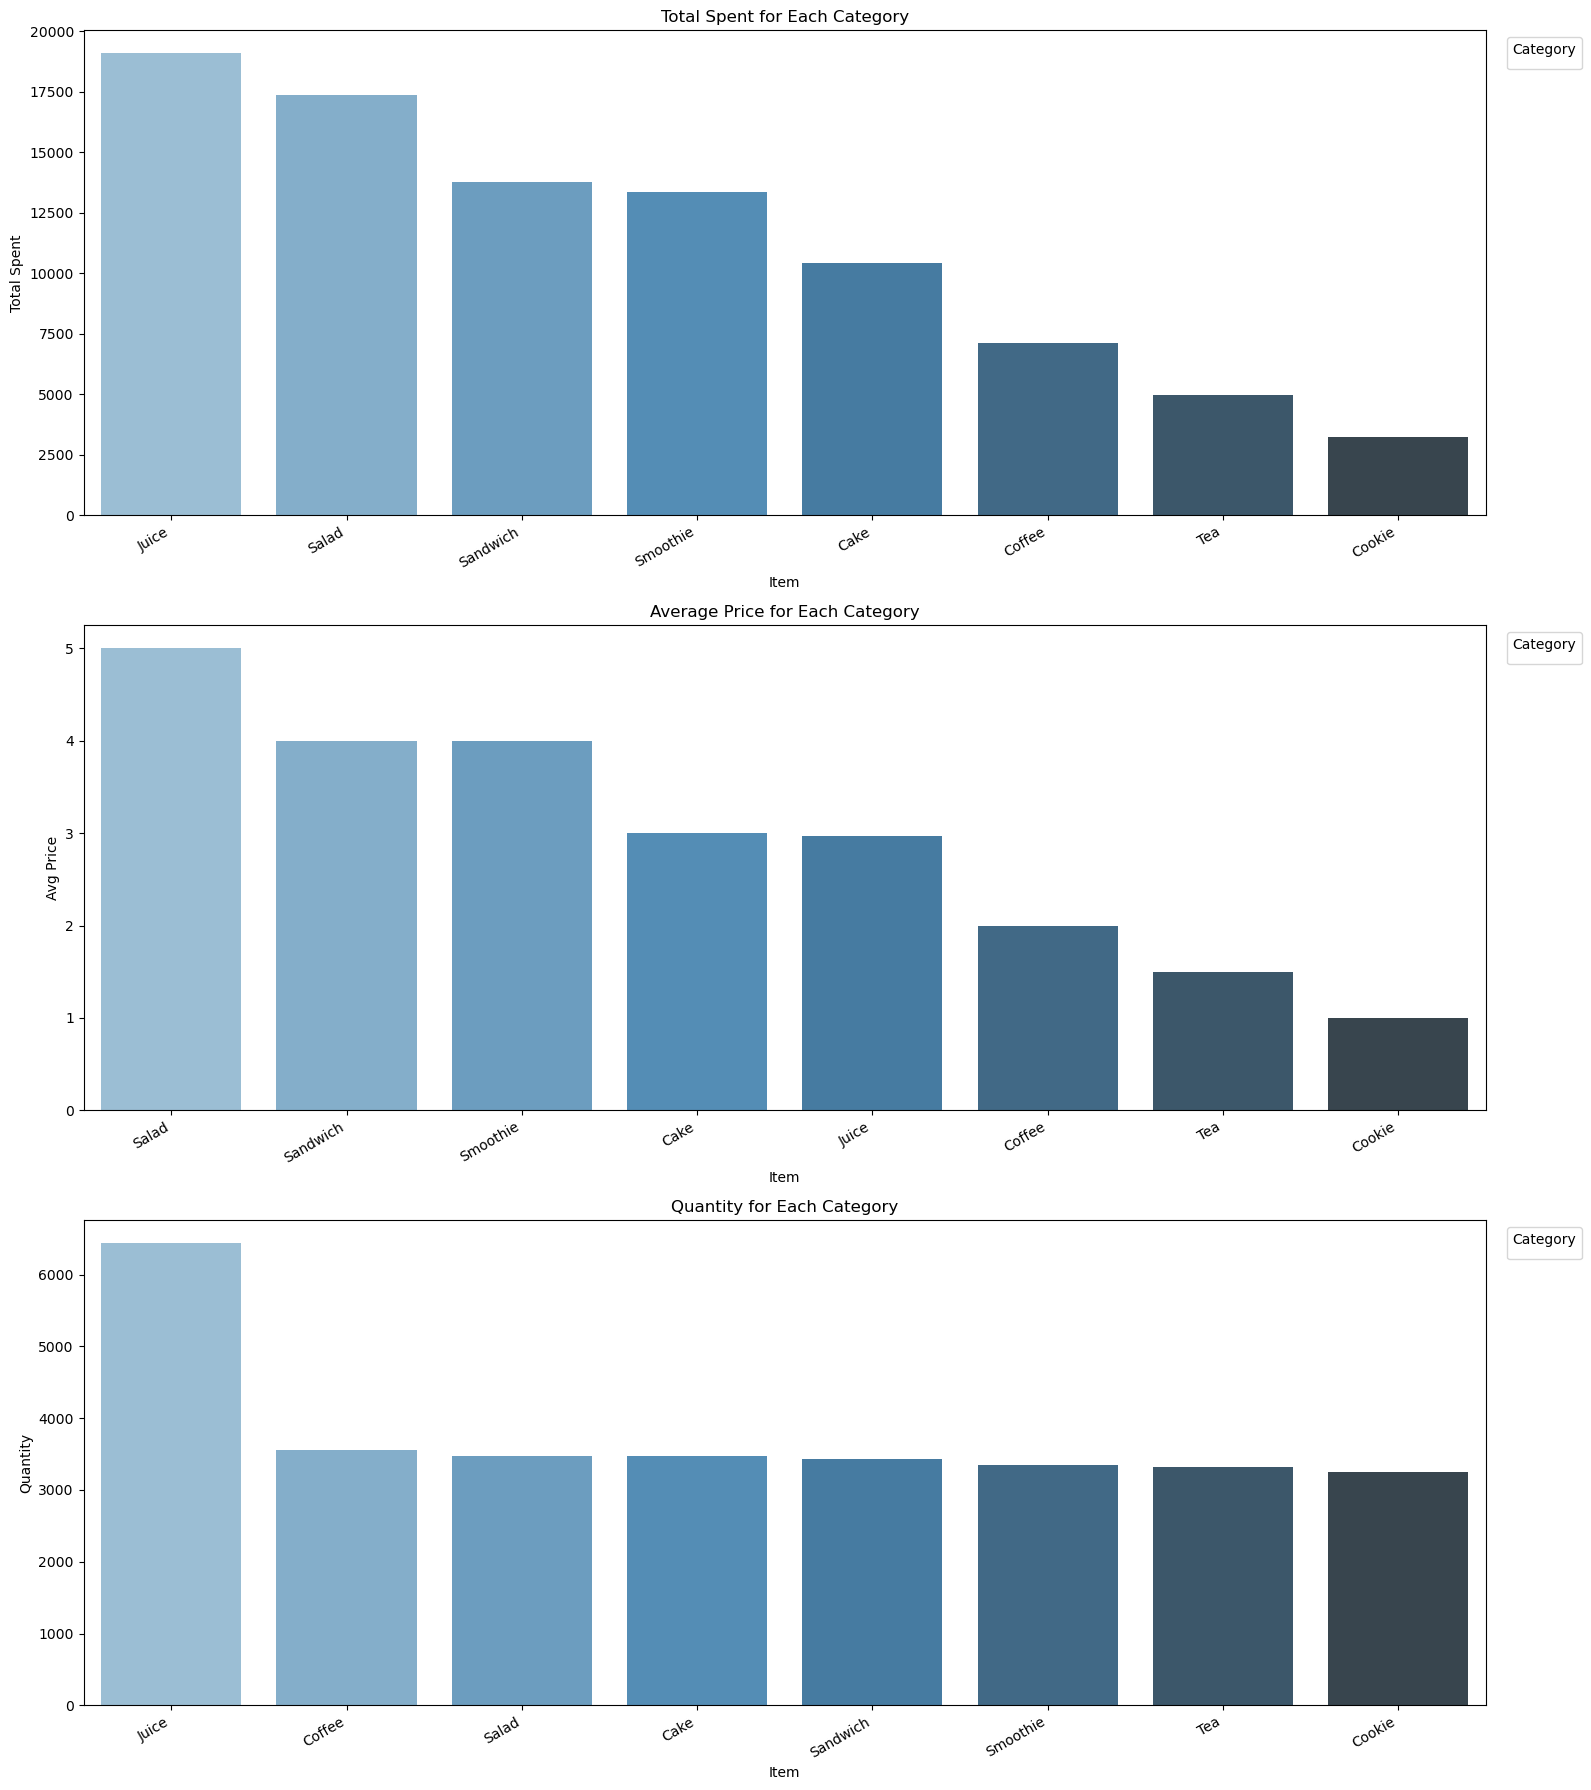

In [171]:
# 8. result_df Barplots
fig, axes = plt.subplots(3, 1, figsize=(16, 18), sharey=False)

sns.barplot(x=result_df.index, y=result_df['Total Spent (sum)'], hue=result_df.index, palette='Blues_d', order=result_df.index, ax=axes[0])
axes[0].set_title('Total Spent for Each Category')
axes[0].set_ylabel('Total Spent')
axes[0].set_xticklabels(labels=result_df.index, rotation=30, ha='right')
axes[0].legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')

result_df_sorted = result_df.sort_values(by='Avg Price', ascending=False)
sns.barplot(x=result_df_sorted.index, y=result_df_sorted['Avg Price'], hue=result_df_sorted.index, palette='Blues_d', order=result_df_sorted.index, ax=axes[1])
axes[1].set_title('Average Price for Each Category')
axes[1].set_ylabel('Avg Price')
axes[1].set_xticklabels(labels=result_df_sorted.index, rotation=30, ha='right')
axes[1].legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')

result_df_sorted = result_df.sort_values(by='Quantity', ascending=False)
sns.barplot(x=result_df_sorted.index, y=result_df_sorted['Quantity'], hue=result_df_sorted.index, palette='Blues_d', order=result_df_sorted.index, ax=axes[2])
axes[2].set_title('Quantity for Each Category')
axes[2].set_ylabel('Quantity')
axes[2].set_xticklabels(labels=result_df_sorted.index, rotation=30, ha='right')
axes[2].legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


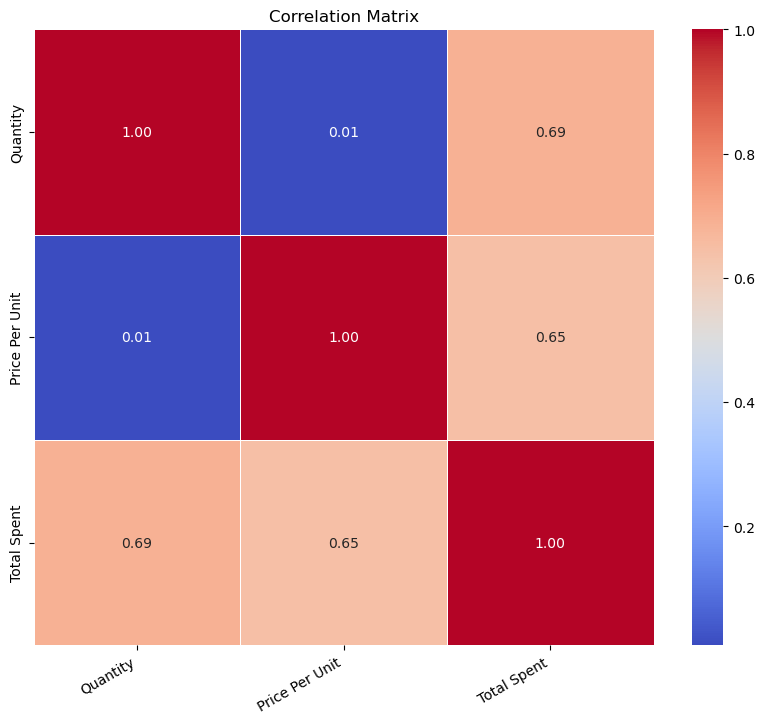

In [172]:
# Correlation Matrix
columns_of_interest = ['Quantity', 'Price Per Unit', 'Total Spent']
correlation_matrix = df[columns_of_interest].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix')
plt.xticks(rotation=30, ha='right')
plt.show()

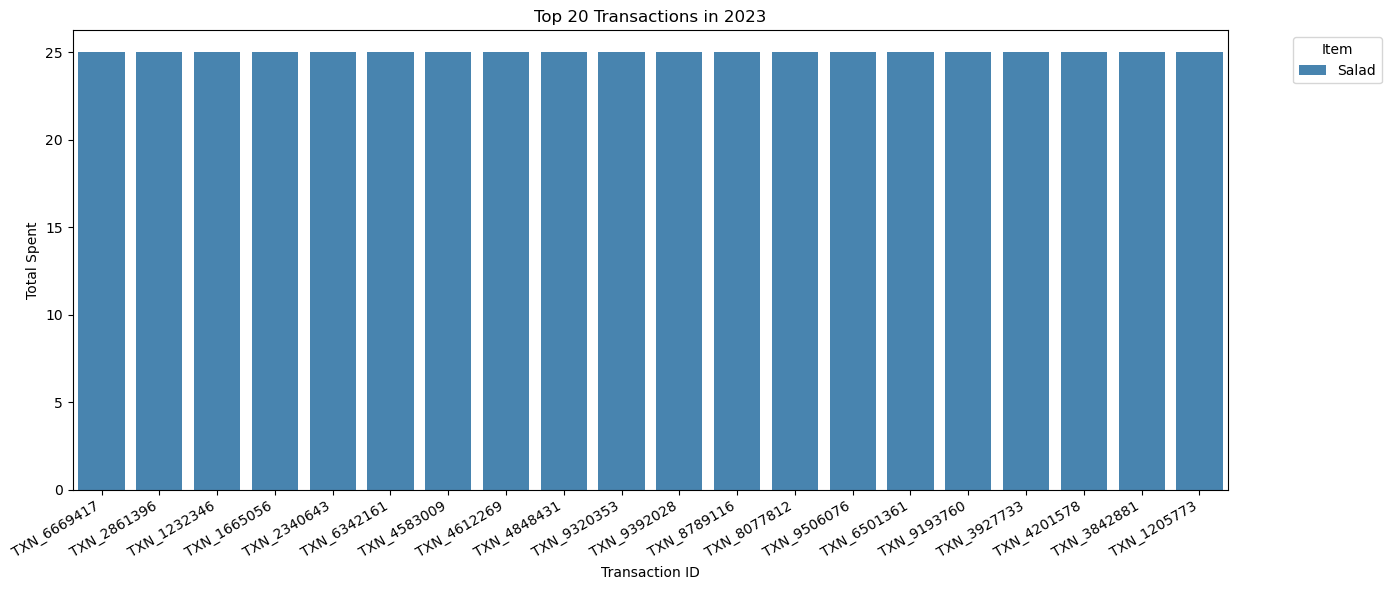


--- Top 20 Transactions ---
    Transaction ID   Item  Total Spent  Price Per Unit  Quantity
60     TXN_6669417  Salad         25.0             5.0         5
78     TXN_2861396  Salad         25.0             5.0         5
83     TXN_1232346  Salad         25.0             5.0         5
112    TXN_1665056  Salad         25.0             5.0         5
113    TXN_2340643  Salad         25.0             5.0         5
192    TXN_6342161  Salad         25.0             5.0         5
196    TXN_4583009  Salad         25.0             5.0         5
227    TXN_4612269  Salad         25.0             5.0         5
231    TXN_4848431  Salad         25.0             5.0         5
250    TXN_9320353  Salad         25.0             5.0         5
325    TXN_9392028  Salad         25.0             5.0         5
334    TXN_8789116  Salad         25.0             5.0         5
407    TXN_8077812  Salad         25.0             5.0         5
431    TXN_9506076  Salad         25.0             5.0       

In [173]:
# Top 20 rows
top_transactions = df[['Transaction ID', 'Item', 'Total Spent', 'Price Per Unit', 'Quantity']].sort_values(by=['Total Spent', 'Quantity'], ascending=False).head(20)

plt.figure(figsize=(14, 6))
sns.barplot(x=top_transactions['Transaction ID'], y=top_transactions['Total Spent'], hue=top_transactions['Item'], data=top_transactions, palette='Blues_d', dodge=False)
plt.title('Top 20 Transactions in 2023')
plt.xlabel('Transaction ID')
plt.ylabel('Total Spent')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Item', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n--- Top 20 Transactions ---")
print(top_transactions)

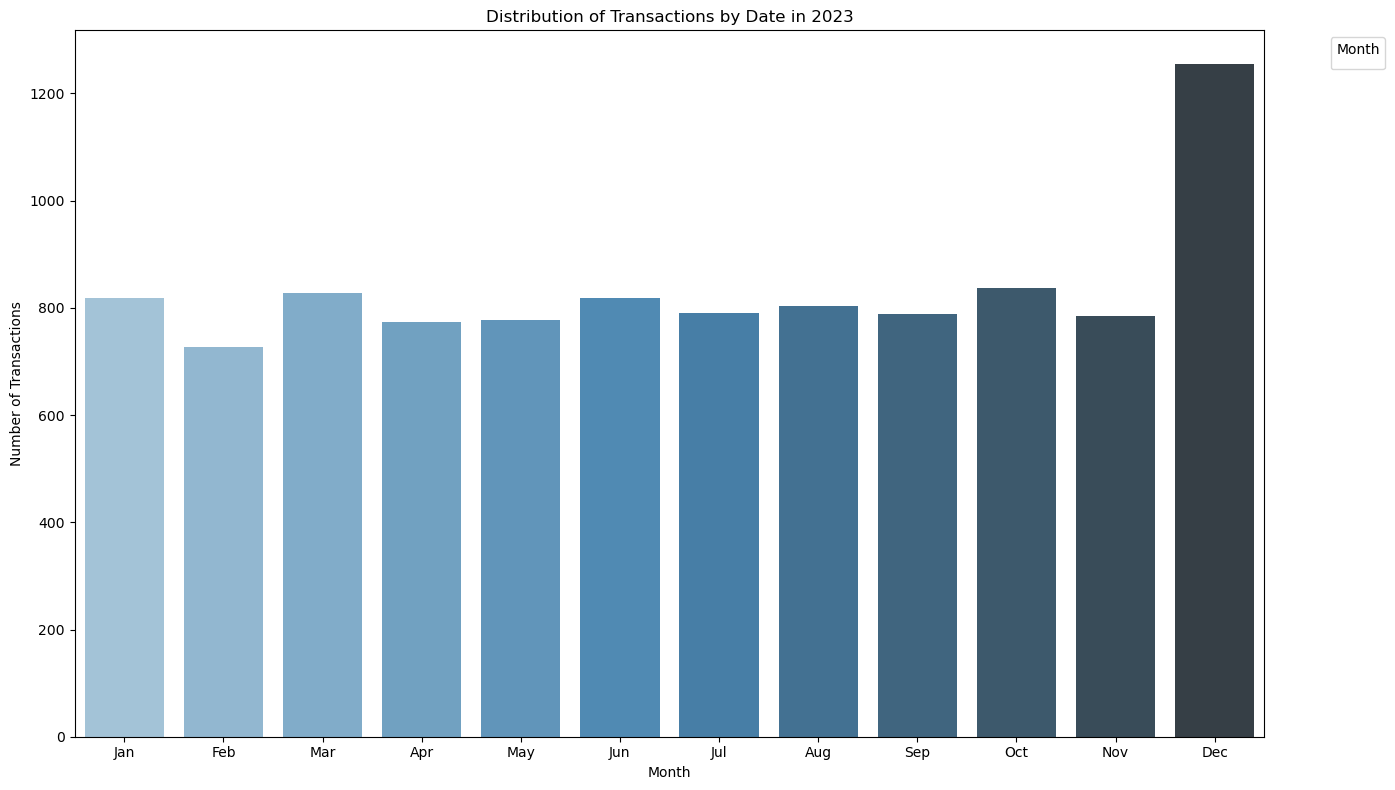


--- Transactions Per Month ---
   Month  Transaction ID
0    Jan             818
1    Feb             727
2    Mar             827
3    Apr             774
4    May             777
5    Jun             818
6    Jul             791
7    Aug             803
8    Sep             788
9    Oct             838
10   Nov             784
11   Dec            1255


In [174]:
# Time Series
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
transactions_2023 = df[df['Transaction Date'].dt.year == 2023]
transactions_per_month = transactions_2023.groupby(transactions_2023['Transaction Date'].dt.month)['Transaction ID'].count().reset_index()
transactions_per_month['Month'] = transactions_per_month['Transaction Date'].apply(lambda x: calendar.month_abbr[x])

plt.figure(figsize=(14, 8))
sns.barplot(data=transactions_per_month, x='Month', y='Transaction ID', hue='Month', palette='Blues_d')
plt.title('Distribution of Transactions by Date in 2023')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n--- Transactions Per Month ---")
print(transactions_per_month[['Month', 'Transaction ID']])

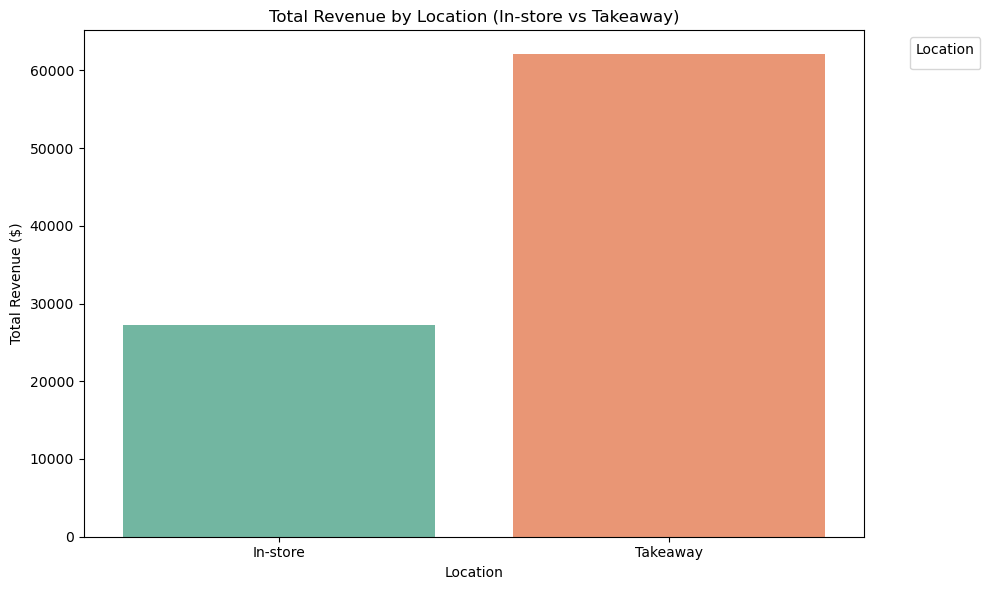

In [175]:
# Revenue by Location
plt.figure(figsize=(10, 6))
location_sales = df.groupby('Location')['Total Spent'].sum().reset_index()
sns.barplot(data=location_sales, x='Location', y='Total Spent', hue='Location', palette='Set2')
plt.title('Total Revenue by Location (In-store vs Takeaway)')
plt.xlabel('Location')
plt.ylabel('Total Revenue ($)')
plt.legend(title='Location', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

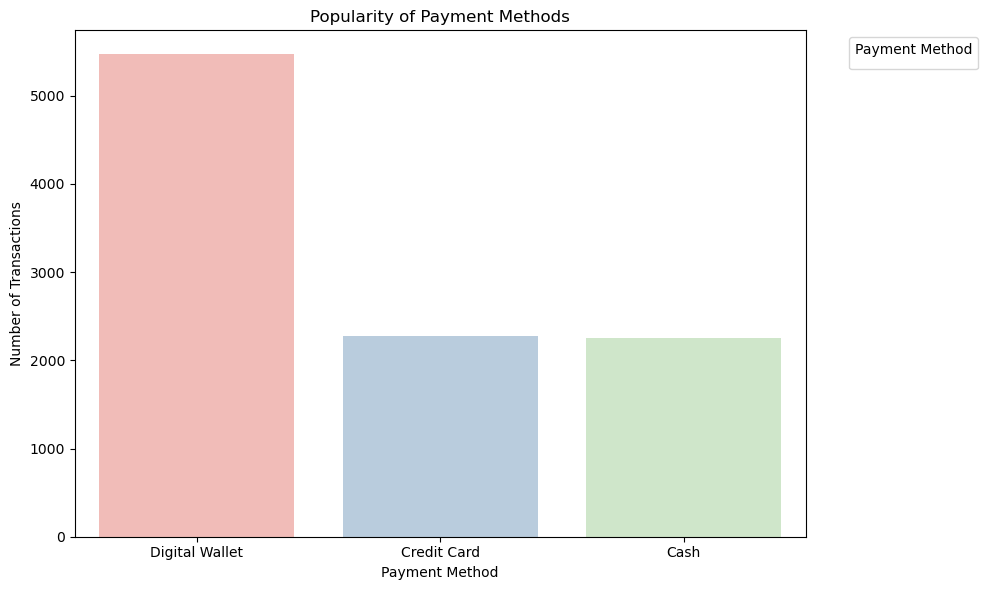

In [176]:
# Additional Insights: Payment Method Distribution
plt.figure(figsize=(10, 6))
payment_counts = df['Payment Method'].value_counts().reset_index()
payment_counts.columns = ['Payment Method', 'Count']
sns.barplot(data=payment_counts, x='Payment Method', y='Count', hue='Payment Method', palette='Pastel1')
plt.title('Popularity of Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.legend(title='Payment Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

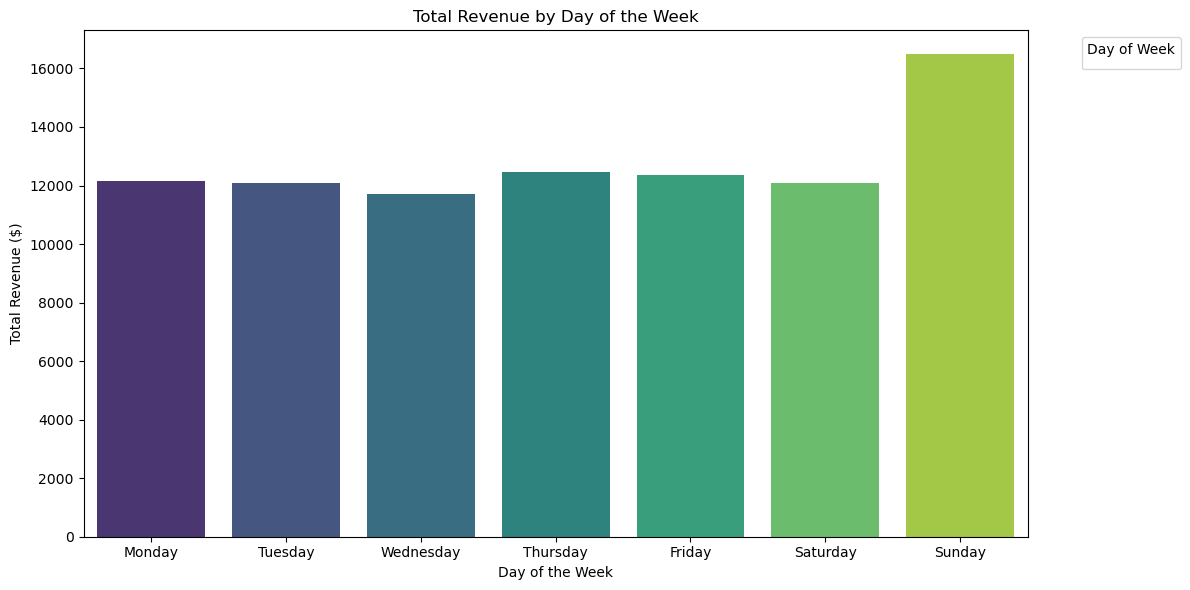

In [177]:
# Additional Insights: Sales by Day of the Week
df['Day of Week'] = df['Transaction Date'].dt.day_name()
# Order the days chronologically
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(12, 6))
day_sales = df.groupby('Day of Week')['Total Spent'].sum().reindex(days_order).reset_index()
sns.barplot(data=day_sales, x='Day of Week', y='Total Spent', hue='Day of Week', palette='viridis')
plt.title('Total Revenue by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Revenue ($)')
plt.legend(title='Day of Week', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

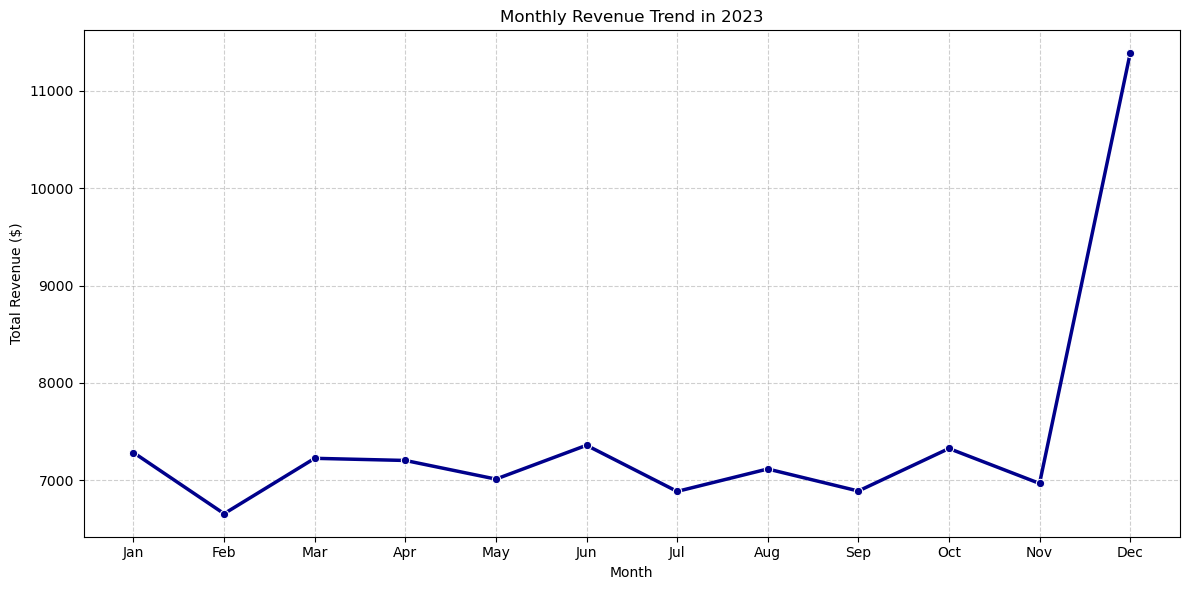

In [178]:
# Additional Insights: Monthly Revenue Trend (Line Plot)
monthly_revenue = transactions_2023.groupby(transactions_2023['Transaction Date'].dt.month)['Total Spent'].sum().reset_index()
monthly_revenue['Month'] = monthly_revenue['Transaction Date'].apply(lambda x: calendar.month_abbr[x])
plt.figure(figsize=(12, 6))
# Line plots are excellent for showing continuous trends over time
sns.lineplot(data=monthly_revenue, x='Month', y='Total Spent', marker='o', color='darkblue', linewidth=2.5)
plt.title('Monthly Revenue Trend in 2023')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()